# Carnet d'ordre - Questions 1.2.3

Ce notebook suit l'ordre du PDF.

Etat actuel :
- Simulation des deux files jusqu'au premier vidage : fait.
- Q1 Approximation brownienne : fait, avec simulations compilees par `numba`.
- Q2 Distribution des temps d'atteinte : fait, avec simulations compilees par `numba`.
- Q3 Temps moyen de premiere atteinte + intervalle de confiance : fait, avec simulations compilees par `numba`.
- Q4 Temps moyen en fonction de Q1(0) et Q-1(0) : fait avec `numba`.
- Q5 Probabilite que Q1 touche zero avant Q-1 : fait avec `numba`.
- Partie 2 Q1 File de Hawkes et intensite stationnaire : fait avec `numba`.

## Parametres et fonctions utiles

Imports, parametres numeriques, fonctions de trace et noyaux de simulation. Les simulations Monte Carlo sont compilees avec `numba` quand c'est possible. Les graphes et les lois exactes de `scipy` restent en Python classique.

In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ModuleNotFoundError:
    NUMBA_DISPONIBLE = False

    def njit(function=None, **kwargs):
        if function is None:
            def decorator(func):
                return func
            return decorator
        return function

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

COULEURS = {
    "ask": "#2563eb",
    "bid": "#dc2626",
    "trajectoire": "#0f766e",
    "simulation": "#60a5fa",
    "exacte": "#f97316",
    "theorie": "#111827",
    "brownien": "#16a34a",
    "accent": "#7c3aed",
}

# Ancien nom conserve pour eviter de casser les cellules deja ecrites.
COLORS = COULEURS

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.facecolor": "white",
    "grid.alpha": 0.35,
})


def habiller_axe(ax, titre=None, xlabel=None, ylabel=None):
    if titre is not None:
        ax.set_title(titre, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, linewidth=0.8, alpha=0.35)
    ax.tick_params(axis="both", labelsize=10)
    return ax


polish_axis = habiller_axe

In [2]:
lambda_plus = 1.2
lambda_minus = 1.5


def simulate_carnet_dordre_until_zero(lambda_plus, lambda_minus, q_a_initial, q_b_initial):
    q_a = [q_a_initial]
    q_b = [q_b_initial]
    times = [0.0]
    t = 0.0
    lambda_total = 2 * (lambda_plus + lambda_minus)

    while q_a[-1] > 0 and q_b[-1] > 0:
        time_step = sps.expon.rvs(scale=1 / lambda_total)
        t += time_step
        times.append(t)
        q_a.append(q_a[-1])
        q_b.append(q_b[-1])

        u = np.random.rand()
        if u < lambda_plus / lambda_total:
            q_a[-1] += 1
        elif u < (lambda_plus + lambda_minus) / lambda_total:
            q_a[-1] -= 1
        elif u < (2 * lambda_plus + lambda_minus) / lambda_total:
            q_b[-1] += 1
        else:
            q_b[-1] -= 1

    return times, q_a, q_b


def simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_initial):
    q = [q_initial]
    times = [0.0]
    t = 0.0
    lambda_total = lambda_plus + lambda_minus

    while q[-1] > 0:
        time_step = sps.expon.rvs(scale=1 / lambda_total)
        t += time_step
        times.append(t)
        if np.random.rand() < lambda_plus / lambda_total:
            q.append(q[-1] + 1)
        else:
            q.append(q[-1] - 1)
    return times, q


@njit
def simuler_etat_poisson_jusqua_T(lambda_plus, lambda_minus, q_initial, T):
    q = q_initial
    t = 0.0
    lambda_total = lambda_plus + lambda_minus
    seuil_plus = lambda_plus / lambda_total

    while True:
        t_suivant = t - np.log(np.random.random()) / lambda_total
        if t_suivant > T:
            break
        t = t_suivant

        if np.random.random() < seuil_plus:
            q += 1
        else:
            q -= 1

    return q


@njit
def simuler_plusieurs_etats_poisson_jusqua_T(lambda_plus, lambda_minus, q_initial, T, nb_simulations):
    etats = np.empty(nb_simulations, dtype=np.int64)

    for k in range(nb_simulations):
        etats[k] = simuler_etat_poisson_jusqua_T(lambda_plus, lambda_minus, q_initial, T)

    return etats


@njit
def simuler_temps_atteinte_poisson(lambda_plus, lambda_minus, q_initial):
    q = q_initial
    t = 0.0
    lambda_total = lambda_plus + lambda_minus
    seuil_plus = lambda_plus / lambda_total

    while q > 0:
        t += -np.log(np.random.random()) / lambda_total
        if np.random.random() < seuil_plus:
            q += 1
        else:
            q -= 1

    return t


@njit
def simuler_plusieurs_temps_atteinte_poisson(lambda_plus, lambda_minus, q_initial, nb_simulations):
    temps = np.empty(nb_simulations)

    for k in range(nb_simulations):
        temps[k] = simuler_temps_atteinte_poisson(lambda_plus, lambda_minus, q_initial)

    return temps


@njit
def simuler_temps_atteinte_brownien(mu, sigma, q_initial, dt=1e-2):
    x = q_initial
    t = 0.0

    while x > 0:
        x += mu * dt + sigma * np.sqrt(dt) * np.random.randn()
        t += dt

    return t


@njit
def simuler_plusieurs_temps_atteinte_brownien(mu, sigma, q_initial, dt, nb_simulations):
    temps = np.empty(nb_simulations)

    for k in range(nb_simulations):
        temps[k] = simuler_temps_atteinte_brownien(mu, sigma, q_initial, dt)

    return temps


@njit
def simuler_temps_et_file_videe(lambda_plus, lambda_minus, q_a_initial, q_b_initial):
    q_a = q_a_initial
    q_b = q_b_initial
    t = 0.0
    lambda_total = 2.0 * (lambda_plus + lambda_minus)

    seuil_a_plus = lambda_plus / lambda_total
    seuil_a_moins = (lambda_plus + lambda_minus) / lambda_total
    seuil_b_plus = (2.0 * lambda_plus + lambda_minus) / lambda_total

    while q_a > 0 and q_b > 0:
        t += -np.log(np.random.random()) / lambda_total

        u_event = np.random.random()
        if u_event < seuil_a_plus:
            q_a += 1
        elif u_event < seuil_a_moins:
            q_a -= 1
        elif u_event < seuil_b_plus:
            q_b += 1
        else:
            q_b -= 1

    q_a_touche_zero = q_a == 0
    return t, q_a_touche_zero


@njit
def estimer_temps_moyen_premiere_atteinte(lambda_plus, lambda_minus, q_a_initial, q_b_initial, nb_simulations=1000):
    somme_temps = 0.0
    somme_temps_carres = 0.0

    for _ in range(nb_simulations):
        temps, _ = simuler_temps_et_file_videe(lambda_plus, lambda_minus, q_a_initial, q_b_initial)
        somme_temps += temps
        somme_temps_carres += temps * temps

    moyenne = somme_temps / nb_simulations
    variance = max(somme_temps_carres / nb_simulations - moyenne * moyenne, 0.0)
    marge = 1.96 * np.sqrt(variance) / np.sqrt(nb_simulations)
    return moyenne, moyenne - marge, moyenne + marge


@njit
def estimer_temps_moyen_atteinte_poisson(lambda_plus, lambda_minus, q_initial, nb_simulations=1000):
    somme_temps = 0.0
    somme_temps_carres = 0.0

    for _ in range(nb_simulations):
        temps = simuler_temps_atteinte_poisson(lambda_plus, lambda_minus, q_initial)
        somme_temps += temps
        somme_temps_carres += temps * temps

    moyenne = somme_temps / nb_simulations
    variance = max(somme_temps_carres / nb_simulations - moyenne * moyenne, 0.0)
    marge = 1.96 * np.sqrt(variance) / np.sqrt(nb_simulations)
    return moyenne, moyenne - marge, moyenne + marge


@njit
def estimer_temps_moyen_premiere_atteinte_grille(lambda_plus, lambda_minus, q_a_values, q_b_values, nb_simulations=300):
    temps_moyens = np.zeros((len(q_a_values), len(q_b_values)))

    for i in range(len(q_a_values)):
        for j in range(len(q_b_values)):
            somme_temps = 0.0
            for _ in range(nb_simulations):
                temps, _ = simuler_temps_et_file_videe(
                    lambda_plus,
                    lambda_minus,
                    q_a_values[i],
                    q_b_values[j],
                )
                somme_temps += temps
            temps_moyens[i, j] = somme_temps / nb_simulations

    return temps_moyens


@njit
def estimer_probabilite_q1_avant_qmoins1(lambda_plus, lambda_minus, q_a_initial, q_b_initial, nb_simulations=1000):
    nb_q1_avant_qmoins1 = 0

    for _ in range(nb_simulations):
        _, q_a_touche_zero = simuler_temps_et_file_videe(
            lambda_plus,
            lambda_minus,
            q_a_initial,
            q_b_initial,
        )
        if q_a_touche_zero:
            nb_q1_avant_qmoins1 += 1

    return nb_q1_avant_qmoins1 / nb_simulations


@njit
def estimer_probabilite_q1_avant_qmoins1_grille(lambda_plus, lambda_minus, q_a_values, q_b_values, nb_simulations=300):
    probabilites = np.zeros((len(q_a_values), len(q_b_values)))

    for i in range(len(q_a_values)):
        for j in range(len(q_b_values)):
            probabilites[i, j] = estimer_probabilite_q1_avant_qmoins1(
                lambda_plus,
                lambda_minus,
                q_a_values[i],
                q_b_values[j],
                nb_simulations,
            )

    return probabilites


# Alias et wrappers conserves pour les anciens noms.
simulate_poisson_process_until_T = simuler_etat_poisson_jusqua_T
time_to_zero_poisson = simuler_temps_atteinte_poisson
time_to_zero_brownian = simuler_temps_atteinte_brownien


def estimate_mean_first_hitting_time_grid(lambda_plus, lambda_minus, q_a_values, q_b_values, num_simulations=300):
    return estimer_temps_moyen_premiere_atteinte_grille(
        lambda_plus,
        lambda_minus,
        q_a_values,
        q_b_values,
        num_simulations,
    )


def estimate_qa_hits_first_probability(lambda_plus, lambda_minus, q_a_initial, q_b_initial, num_simulations=1000):
    return estimer_probabilite_q1_avant_qmoins1(
        lambda_plus,
        lambda_minus,
        q_a_initial,
        q_b_initial,
        num_simulations,
    )


def estimate_q_a_hits_first_probability_grid(lambda_plus, lambda_minus, q_a_values, q_b_values, num_simulations=300):
    return estimer_probabilite_q1_avant_qmoins1_grille(
        lambda_plus,
        lambda_minus,
        q_a_values,
        q_b_values,
        num_simulations,
    )


def tracer_files_en_fonction_du_temps(lambda_plus, lambda_minus, q_a_initial, q_b_initial):
    times, q_a, q_b = simulate_carnet_dordre_until_zero(
        lambda_plus, lambda_minus, q_a_initial, q_b_initial
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(times, q_a, where="post", label="File q_a", color=COULEURS["ask"], linewidth=2.2)
    ax.step(times, q_b, where="post", label="File q_b", color=COULEURS["bid"], linewidth=2.2)
    ax.scatter(times[-1], q_a[-1], color=COULEURS["ask"], s=55, zorder=3)
    ax.scatter(times[-1], q_b[-1], color=COULEURS["bid"], s=55, zorder=3)
    ax.axhline(0, color="#111827", linewidth=1, alpha=0.55)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    habiller_axe(
        ax,
        titre="Simulation des deux files jusqu'au premier vidage",
        xlabel="Temps",
        ylabel="Taille de la file",
    )
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


def tracer_trajectoire_carnet_dordre(lambda_plus, lambda_minus, q_a_initial, q_b_initial):
    times, q_a, q_b = simulate_carnet_dordre_until_zero(
        lambda_plus, lambda_minus, q_a_initial, q_b_initial
    )

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.plot(q_a, q_b, color=COULEURS["trajectoire"], linewidth=2, alpha=0.9, label="Trajectoire")
    ax.scatter(q_a[0], q_b[0], color=COULEURS["accent"], s=80, label="Depart", zorder=3)
    ax.scatter(q_a[-1], q_b[-1], color="#111827", s=80, label="Arret", zorder=3)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_aspect("equal", adjustable="box")

    habiller_axe(
        ax,
        titre="Trajectoire dans le quadrant bid-ask",
        xlabel="q_a",
        ylabel="q_b",
    )
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


# Alias conserves pour les anciens noms de trace.
plot_carnet_dordre_fct_t = tracer_files_en_fonction_du_temps
trajectory_carnet_dordre = tracer_trajectoire_carnet_dordre

## Preamble - Simulate The Two Queues Until One Hits Zero

Status: done. This is the initial simulation requested before the numbered questions.

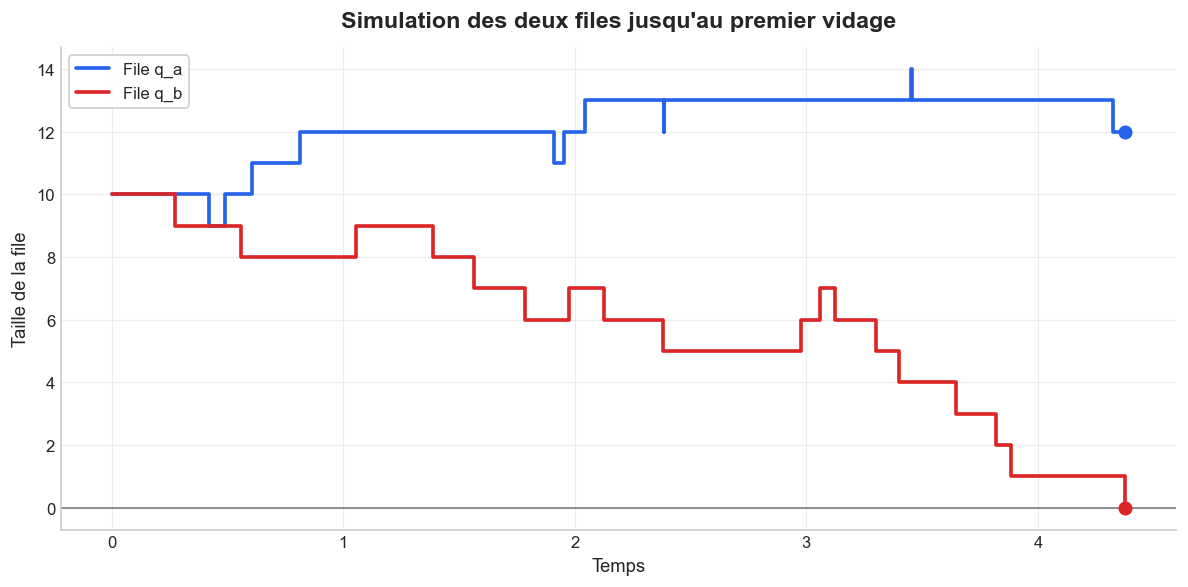

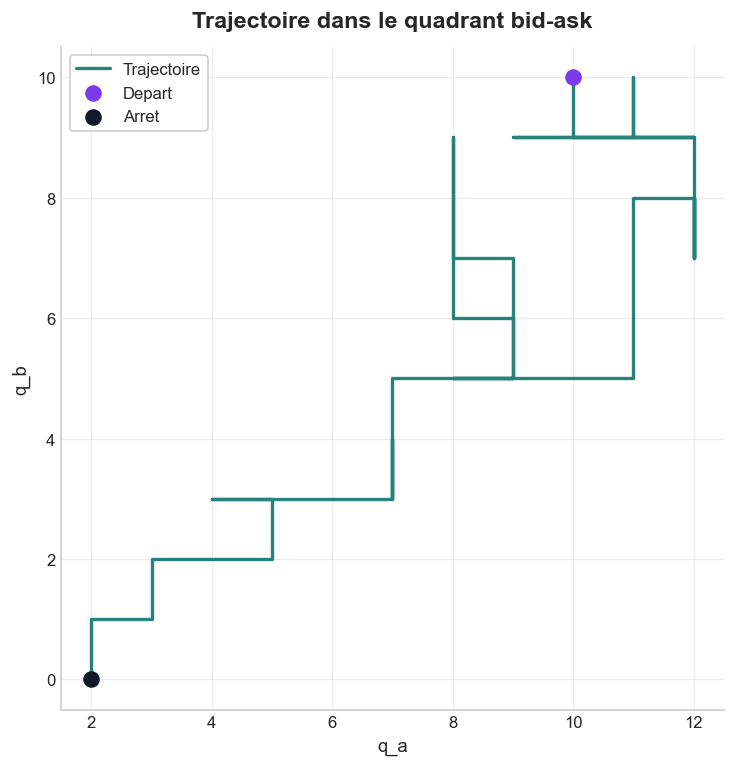

In [3]:
tracer_files_en_fonction_du_temps(lambda_plus, lambda_minus, 10, 10)
tracer_trajectoire_carnet_dordre(lambda_plus, lambda_minus, 10, 10)

## Q1 - Approximation brownienne d'une file

Pour une seule file, on peut ecrire `Q(t) = Q(0) + N_+(t) - N_-(t)`, avec `N_+` et `N_-` deux processus de Poisson independants d'intensites `lambda_plus` et `lambda_minus`. Ainsi, l'accroissement moyen par unite de temps est `lambda_plus - lambda_minus`, et la variance par unite de temps est `lambda_plus + lambda_minus`. A grande echelle, `Q(t)` s'approxime donc par un mouvement brownien arithmetique de drift `lambda_plus - lambda_minus` et de variance instantanee `sigma^2 = lambda_plus + lambda_minus`.

In [4]:
# La fonction `simulate_poisson_process_until_T` est maintenant un alias compile par numba
# de `simuler_etat_poisson_jusqua_T`, definie dans la cellule de setup.

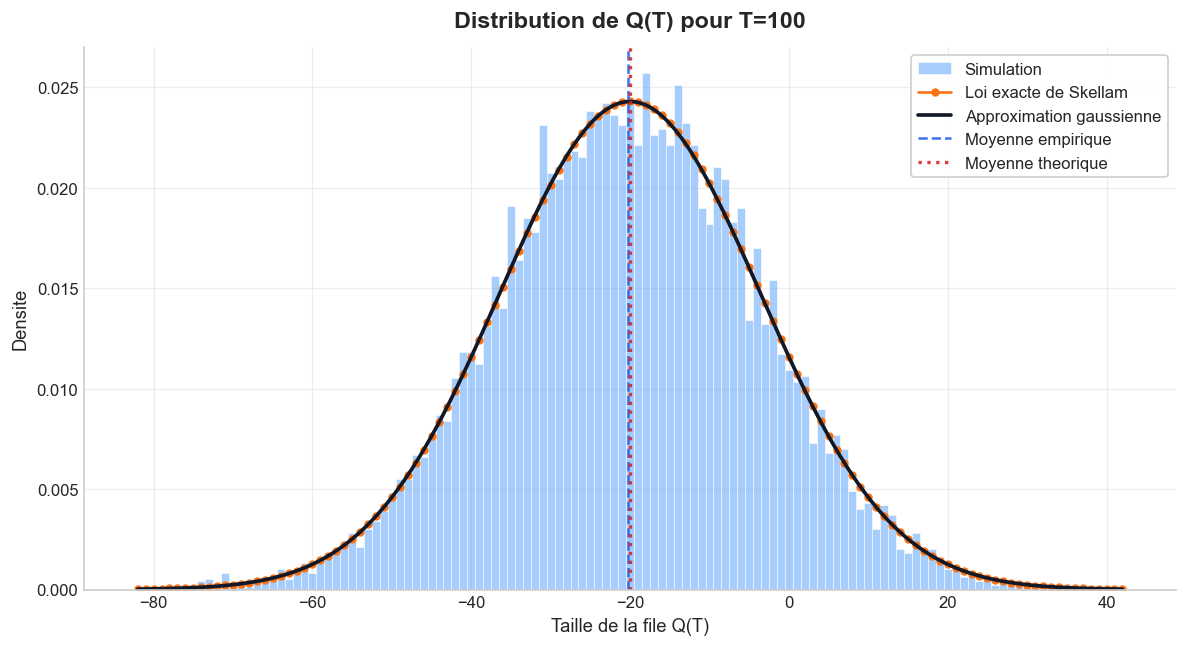

Moyenne empirique : -20.23
Variance empirique : 265.41
Moyenne theorique : -20.00
Variance theorique : 270.00


In [5]:
N = 10000
q_0 = 10
lambda_plus = 1.2
lambda_minus = 1.5
T = 100
Q = simuler_plusieurs_etats_poisson_jusqua_T(lambda_plus, lambda_minus, q_0, T, N)

mu = q_0 + (lambda_plus - lambda_minus) * T
sigma = np.sqrt((lambda_plus + lambda_minus) * T)
k = np.arange(Q.min(), Q.max() + 1)
pmf_exacte = sps.skellam.pmf(k - q_0, mu1=lambda_plus * T, mu2=lambda_minus * T)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    Q,
    bins=np.arange(Q.min() - 0.5, Q.max() + 1.5, 1),
    density=True,
    alpha=0.55,
    color=COULEURS["simulation"],
    edgecolor="white",
    linewidth=0.6,
    label="Simulation",
)
ax.plot(k, pmf_exacte, "o-", color=COULEURS["exacte"], markersize=4, linewidth=1.6, label="Loi exacte de Skellam")
x = np.linspace(Q.min(), Q.max(), 300)
ax.plot(x, sps.norm.pdf(x, loc=mu, scale=sigma), color=COULEURS["theorie"], linewidth=2.2, label="Approximation gaussienne")
ax.axvline(Q.mean(), color=COULEURS["ask"], linestyle="--", linewidth=1.5, alpha=0.9, label="Moyenne empirique")
ax.axvline(mu, color=COULEURS["bid"], linestyle=":", linewidth=2, alpha=0.9, label="Moyenne theorique")

habiller_axe(
    ax,
    titre=f"Distribution de Q(T) pour T={T}",
    xlabel="Taille de la file Q(T)",
    ylabel="Densite",
)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

print(f'Moyenne empirique : {Q.mean():.2f}')
print(f'Variance empirique : {Q.var():.2f}')
print(f'Moyenne theorique : {mu:.2f}')
print(f'Variance theorique : {(lambda_plus + lambda_minus) * T:.2f}')

## Q2 - Distribution Of Hitting Times

Status: partial. The plot below compares Poisson first hitting times with Brownian simulated hitting times and the Brownian theoretical density. The `sigma` formula is now `sqrt(lambda_plus + lambda_minus)`.

In [6]:
# Les fonctions suivantes sont maintenant compilees par numba et definies dans la cellule de setup :
# - time_to_zero_poisson = simuler_temps_atteinte_poisson
# - time_to_zero_brownian = simuler_temps_atteinte_brownien

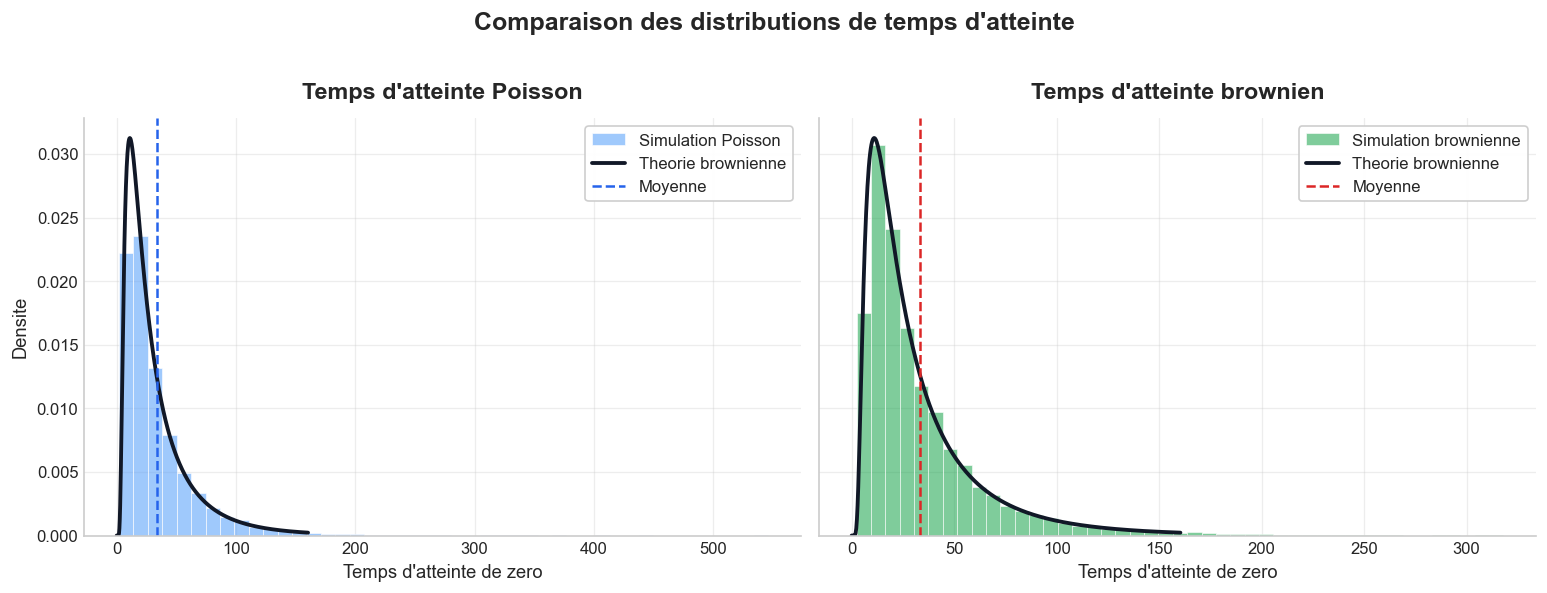

In [7]:
N = 10000

lambda_plus = 1.2
lambda_minus = 1.5
mu = lambda_plus - lambda_minus
sigma = np.sqrt(lambda_plus + lambda_minus)
q_0 = 10
dt_brownien = 1e-2

poisson_times_to_zero = simuler_plusieurs_temps_atteinte_poisson(lambda_plus, lambda_minus, q_0, N)
brownian_times_to_zero = simuler_plusieurs_temps_atteinte_brownien(mu, sigma, q_0, dt_brownien, N)


def brownian_hitting_density(x, q_0, mu, sigma):
    x = np.asarray(x)
    density = np.zeros_like(x, dtype=float)
    positive = x > 0
    density[positive] = (
        q_0
        / (sigma * np.sqrt(2 * np.pi * x[positive] ** 3))
        * np.exp(-(q_0 + mu * x[positive]) ** 2 / (2 * x[positive] * sigma ** 2))
    )
    return density

max_time = np.percentile(np.concatenate([poisson_times_to_zero, brownian_times_to_zero]), 99)
x = np.linspace(1e-6, max_time, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

axes[0].hist(
    poisson_times_to_zero,
    bins=45,
    density=True,
    color=COULEURS["simulation"],
    alpha=0.6,
    edgecolor="white",
    linewidth=0.6,
    label="Simulation Poisson",
)
axes[0].plot(x, brownian_hitting_density(x, q_0, mu, sigma), color=COULEURS["theorie"], linewidth=2.3, label="Theorie brownienne")
axes[0].axvline(poisson_times_to_zero.mean(), color=COULEURS["ask"], linestyle="--", linewidth=1.5, label="Moyenne")
habiller_axe(axes[0], titre="Temps d'atteinte Poisson", xlabel="Temps d'atteinte de zero", ylabel="Densite")
axes[0].legend(loc="best")

axes[1].hist(
    brownian_times_to_zero,
    bins=45,
    density=True,
    color=COULEURS["brownien"],
    alpha=0.55,
    edgecolor="white",
    linewidth=0.6,
    label="Simulation brownienne",
)
axes[1].plot(x, brownian_hitting_density(x, q_0, mu, sigma), color=COULEURS["theorie"], linewidth=2.3, label="Theorie brownienne")
axes[1].axvline(brownian_times_to_zero.mean(), color=COULEURS["bid"], linestyle="--", linewidth=1.5, label="Moyenne")
habiller_axe(axes[1], titre="Temps d'atteinte brownien", xlabel="Temps d'atteinte de zero")
axes[1].legend(loc="best")

fig.suptitle("Comparaison des distributions de temps d'atteinte", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## Q3 - Mean First Hitting Time And Confidence Interval

Status: mostly done. This estimates the mean time until one of the two queues hits zero and computes a confidence interval. Check that the parameters are consistent with the PDF example before using the result.

In [8]:
def estimate_time_to_zero(lambda_plus, lambda_minus, q_a_initial, q_b_initial, num_simulations=1000):
    return estimer_temps_moyen_premiere_atteinte(
        lambda_plus,
        lambda_minus,
        q_a_initial,
        q_b_initial,
        num_simulations,
    )


mean_time, ci_lower, ci_upper = estimate_time_to_zero(lambda_plus, lambda_minus, 10, 10)
print(f"Temps moyen estime avant le premier vidage : {mean_time:.2f}")
print(f"Intervalle de confiance a 95% : [{ci_lower:.2f}, {ci_upper:.2f}]")

Temps moyen estime avant le premier vidage : 18.35
Intervalle de confiance a 95% : [17.50, 19.21]


## Extra Check - One Queue Mean Hitting Time

This is useful for comparison with the theoretical mean `q_0 / (lambda_minus - lambda_plus)`, but it is not one of the missing Q4/Q5 tasks.

In [9]:
def estimate_time_to_zero_for_one_process(lambda_plus, lambda_minus, q_initial, num_simulations=1000):
    return estimer_temps_moyen_atteinte_poisson(
        lambda_plus,
        lambda_minus,
        q_initial,
        num_simulations,
    )


mean_time, ci_lower, ci_upper = estimate_time_to_zero_for_one_process(lambda_plus, lambda_minus, 10)
print(f"Temps moyen estime pour une file : {mean_time:.2f}")
print(f"Intervalle de confiance a 95% : [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Temps moyen theorique : {10 / (lambda_minus - lambda_plus):.2f}")

Temps moyen estime pour une file : 32.43
Intervalle de confiance a 95% : [30.71, 34.15]
Temps moyen theorique : 33.33


## Q4 - Temps moyen de premiere atteinte en fonction des tailles initiales

Status: implemente avec `numba`. On estime le temps moyen avant que la premiere des deux files touche zero, en fonction de `Q_1(0)` et `Q_{-1}(0)`.

In [10]:
# Les fonctions compilees par numba sont definies dans la cellule de setup.

grille_q = np.arange(1, 21)
nb_simulations_q4 = 1000

grille_temps_moyens = estimer_temps_moyen_premiere_atteinte_grille(
    lambda_plus=1.2,
    lambda_minus=1.5,
    q_a_values=grille_q,
    q_b_values=grille_q,
    nb_simulations=nb_simulations_q4,
)

# Alias pour garder l'ancien nom de la grille.
q_values = grille_q
mean_times_grid = grille_temps_moyens

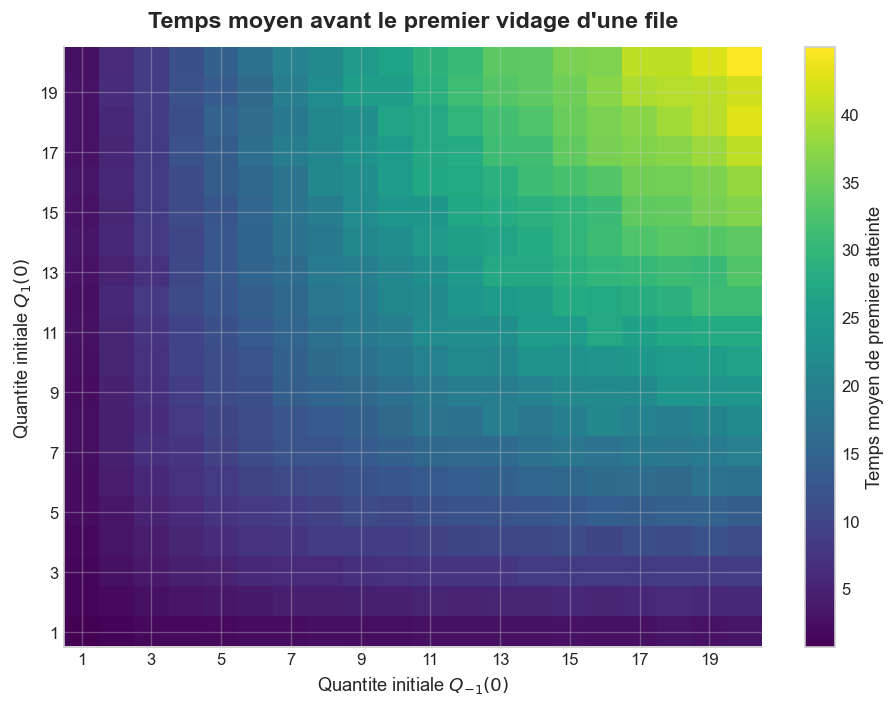

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    grille_temps_moyens,
    origin="lower",
    cmap="viridis",
    extent=[
        grille_q[0] - 0.5,
        grille_q[-1] + 0.5,
        grille_q[0] - 0.5,
        grille_q[-1] + 0.5,
    ],
    aspect="auto",
)

fig.colorbar(im, ax=ax, label="Temps moyen de premiere atteinte")

habiller_axe(
    ax,
    titre="Temps moyen avant le premier vidage d'une file",
    xlabel=r"Quantite initiale $Q_{-1}(0)$",
    ylabel=r"Quantite initiale $Q_1(0)$",
)

ax.set_xticks(grille_q[::2])
ax.set_yticks(grille_q[::2])
fig.tight_layout()
plt.show()

## Q5 - Probabilite que Q1 touche zero avant Q-1

Status: implemente avec `numba`. On estime la probabilite que `Q_1` touche zero avant `Q_{-1}`, en fonction de `Q_1(0)` et `Q_{-1}(0)`.

In [12]:
# Les fonctions compilees par numba sont definies dans la cellule de setup.

grille_q_q5 = np.arange(1, 21)
nb_simulations_q5 = 1000

grille_probabilites_q1 = estimer_probabilite_q1_avant_qmoins1_grille(
    lambda_plus=1.2,
    lambda_minus=1.5,
    q_a_values=grille_q_q5,
    q_b_values=grille_q_q5,
    nb_simulations=nb_simulations_q5,
)

# Alias pour garder l'ancien nom de la grille.
q_values_q5 = grille_q_q5
qa_hits_first_probability_grid = grille_probabilites_q1

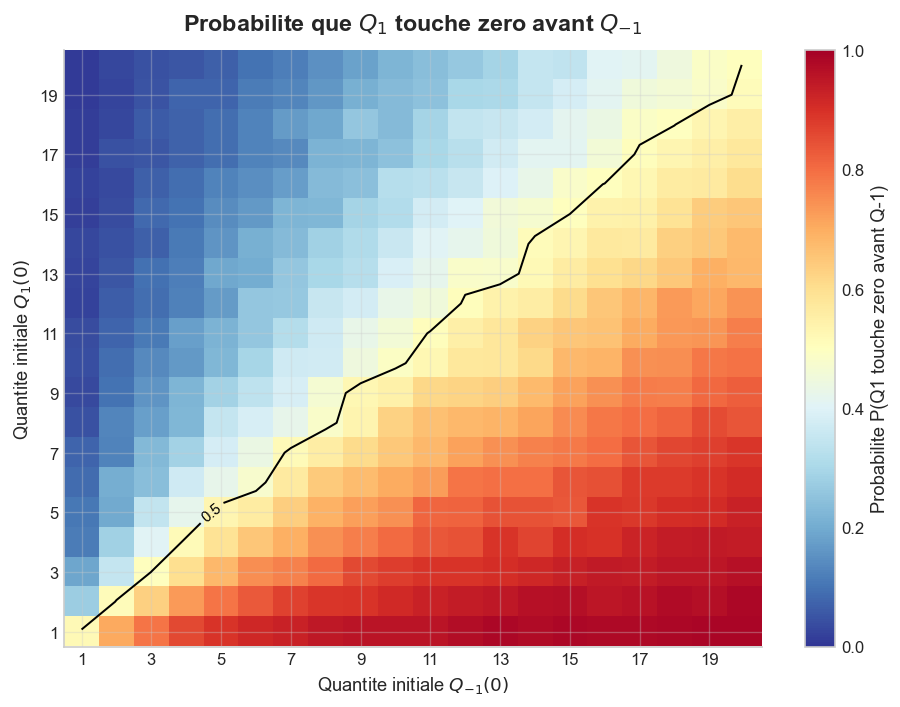

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    grille_probabilites_q1,
    origin="lower",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    extent=[
        grille_q_q5[0] - 0.5,
        grille_q_q5[-1] + 0.5,
        grille_q_q5[0] - 0.5,
        grille_q_q5[-1] + 0.5,
    ],
    aspect="auto",
)

if grille_probabilites_q1.min() <= 0.5 <= grille_probabilites_q1.max():
    contour = ax.contour(
        grille_q_q5,
        grille_q_q5,
        grille_probabilites_q1,
        levels=[0.5],
        colors="black",
        linewidths=1.2,
    )
    ax.clabel(contour, fmt={0.5: "0.5"}, inline=True, fontsize=9)

fig.colorbar(im, ax=ax, label="Probabilite P(Q1 touche zero avant Q-1)")

habiller_axe(
    ax,
    titre=r"Probabilite que $Q_1$ touche zero avant $Q_{-1}$",
    xlabel=r"Quantite initiale $Q_{-1}(0)$",
    ylabel=r"Quantite initiale $Q_1(0)$",
)

ax.set_xticks(grille_q_q5[::2])
ax.set_yticks(grille_q_q5[::2])
fig.tight_layout()
plt.show()

# Partie 2 - Questions 1.2.4

## Q1 - Simulation d'une file de Hawkes et intensite stationnaire

In [14]:
def trajectoire_carnet_dordre_hawkes(mu_minus,alpha,beta,lambda_plus,q_0,stopping_condition):
    q=q_0
    t=0
    lambda_bar= mu_minus
    lambda_minus_t=mu_minus
    lambda_minus_list=[lambda_minus_t]
    times = [t]
    q_values = [q]
    while not stopping_condition(q,t):
        lambda_bar=max(lambda_minus_t,mu_minus)
        lambda_sup=lambda_bar+lambda_plus
        delta_t=np.random.exponential(1/lambda_sup) 
        lambda_minus_t=mu_minus+(lambda_minus_t-mu_minus)*np.exp(-beta*delta_t)
        t+=delta_t
        times.append(t)
        lambda_eff=max(lambda_minus_t,0)
        U=np.random.rand()
        if U<lambda_plus/lambda_sup:
            q+=1
            q_values.append(q)
            lambda_minus_t-=alpha
            lambda_minus_list.append(lambda_minus_t)
        elif U<lambda_eff/lambda_sup:
            q-=1
            q_values.append(q)
            lambda_minus_t+=alpha
            lambda_minus_list.append(lambda_minus_t)
        else:
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
    return times,q_values,lambda_minus_list

def plot_hawkes_trajectory(times,q_values,lambda_minus_list): # draw in separate subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ax1.step(times, q_values, where="post", label="File q", color=COULEURS["trajectoire"], linewidth=2.2)
    ax1.set_ylabel("Taille de la file q(t)", color=COULEURS["trajectoire"])
    ax1.tick_params(axis='y', labelcolor=COULEURS["trajectoire"])
    ax1.grid(True, linewidth=0.8, alpha=0.35)
    ax1.legend(loc="best")
    
    ax2.plot(times, lambda_minus_list, label="Intensite Hawkes lambda_minus(t)", color=COULEURS["accent"], linewidth=2.2)
    ax2.set_xlabel("Temps")
    ax2.set_ylabel("Intensite Hawkes lambda_minus(t)", color=COULEURS["accent"])
    ax2.tick_params(axis='y', labelcolor=COULEURS["accent"])
    ax2.grid(True, linewidth=0.8, alpha=0.35)
    ax2.legend(loc="best")
    
    fig.suptitle("Trajectoire du carnet d'ordre et de l'intensite Hawkes", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

def plot_lambda_minus_over_time(times, lambda_minus_list):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(times, lambda_minus_list, label="Intensite Hawkes", color=COULEURS["accent"], linewidth=2.2)
    ax.set_xlabel("Temps")
    ax.set_ylabel("Intensite Hawkes lambda_minus(t)", color=COULEURS["accent"])
    ax.tick_params(axis='y', labelcolor=COULEURS["accent"])
    ax.grid(True, linewidth=0.8, alpha=0.35)
    fig.suptitle("Evolution de l'intensite Hawkes dans le temps", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

def distribution_last_lambda_minus(lambda_minus_list):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(lambda_minus_list, bins=30, density=True, color=COULEURS["accent"], alpha=0.6, edgecolor="white", linewidth=0.6)
    ax.set_xlabel("Intensite Hawkes lambda_minus(t)", color=COULEURS["accent"])
    ax.set_ylabel("Densite", color=COULEURS["accent"])
    ax.tick_params(axis='y', labelcolor=COULEURS["accent"])
    ax.grid(True, linewidth=0.8, alpha=0.35)
    fig.suptitle("Distribution de l'intensite Hawkes lambda_minus(t)", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()


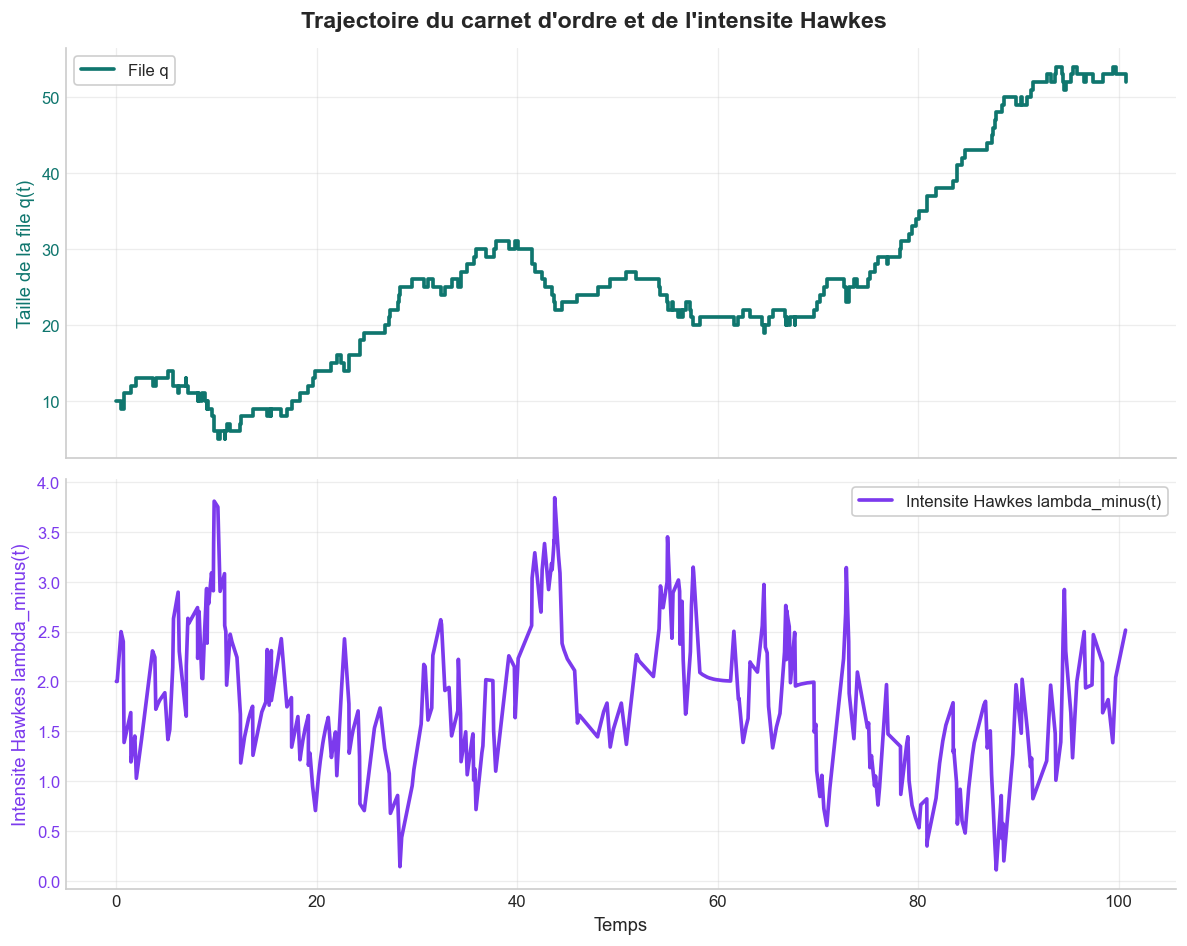

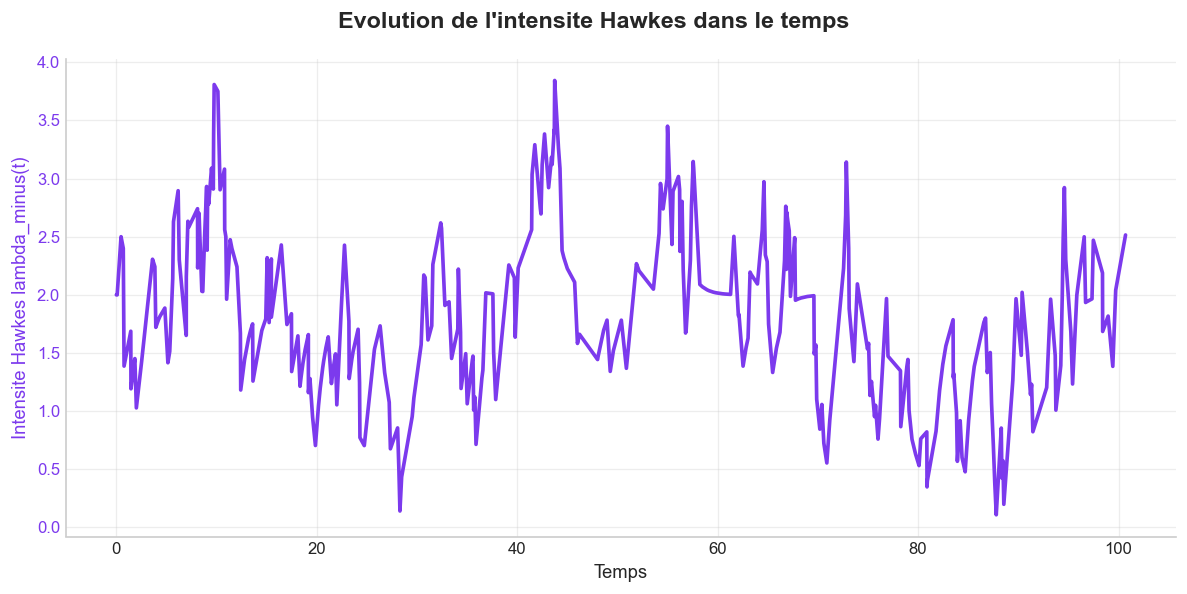

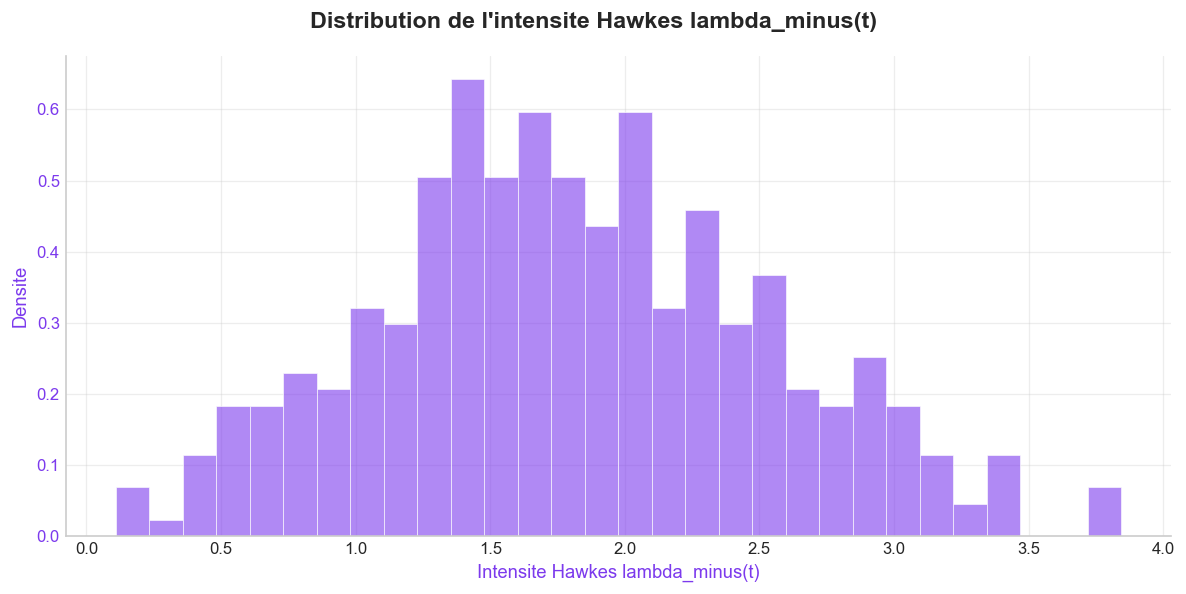

In [15]:
times,q_values,lambda_minus_list = trajectoire_carnet_dordre_hawkes(mu_minus=2, alpha=0.5, beta=1.0, lambda_plus=1.2, q_0=10, stopping_condition=lambda q,t: t>100)
plot_hawkes_trajectory(times, q_values, lambda_minus_list)
plot_lambda_minus_over_time(times, lambda_minus_list)
distribution_last_lambda_minus(lambda_minus_list)

In [16]:
def simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a,q_0_b):
    q_a = q_0_a
    q_b = q_0_b
    t = 0
    t_last_a = 0
    t_last_b = 0
    lambda_bar_a = mu_minus_a
    lambda_bar_b = mu_minus_b
    lambda_minus_a_t = mu_minus_a
    lambda_minus_b_t = mu_minus_b
    times = [t]
    times_a = [t]
    times_b = [t]
    q_a_values = [q_a]
    q_b_values = [q_b]
    while q_a > 0 and q_b > 0:
        lambda_bar_a = max(mu_minus_a, lambda_minus_a_t)
        lambda_bar_b = max(mu_minus_b, lambda_minus_b_t)
        sup_lambda = lambda_bar_a + lambda_bar_b + lambda_plus_a + lambda_plus_b
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre_a = mu_minus_a + (lambda_minus_a_t - mu_minus_a) * np.exp(-beta * (t_prime - t_last_a))
        lambda_pre_b = mu_minus_b + (lambda_minus_b_t - mu_minus_b) * np.exp(-beta * (t_prime - t_last_b))
        lambda_eff_a = max(lambda_pre_a, 0)
        lambda_eff_b = max(lambda_pre_b, 0)
        U = np.random.rand()
        if U < lambda_plus_a / sup_lambda:
            q_a += 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a - alpha
            lambda_minus_b_t = lambda_pre_b + alpha
            times.append(t)
            times_a.append(t)
            q_a_values.append(q_a)
        elif U < (lambda_eff_a+lambda_plus_a) / sup_lambda:
            q_a -= 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a + alpha
            lambda_minus_b_t = lambda_pre_b - alpha
            times.append(t)
            times_a.append(t)   
            q_a_values.append(q_a)
        elif U < (lambda_bar_a+lambda_plus_a) / sup_lambda:
            lambda_minus_a_t = lambda_pre_a
            lambda_minus_b_t = lambda_pre_b
            t_last_a = t_prime
            t = t_prime
        elif U < (lambda_bar_a+lambda_plus_a+lambda_plus_b) / sup_lambda:
            q_b += 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b - alpha
            lambda_minus_a_t = lambda_pre_a + alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        elif U < (lambda_bar_a+lambda_plus_a+lambda_eff_b+lambda_plus_b) / sup_lambda:
            q_b -= 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b + alpha
            lambda_minus_a_t = lambda_pre_a - alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        else:
            lambda_minus_b_t = lambda_pre_b
            lambda_minus_a_t = lambda_pre_a
            t_last_b = t_prime
            t = t_prime
    return times, times_a, times_b, q_a_values, q_b_values


def plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.tight_layout()
    plt.grid()
    plt.show()
    
def plot_stopping_time_distribution_coupled_hawkes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times,_ ,_ , _, _ = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='purple', label='Simulation Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q_a ou q_b atteigne zéro (Hawkes couplé)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour les processus Hawkes couplés")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

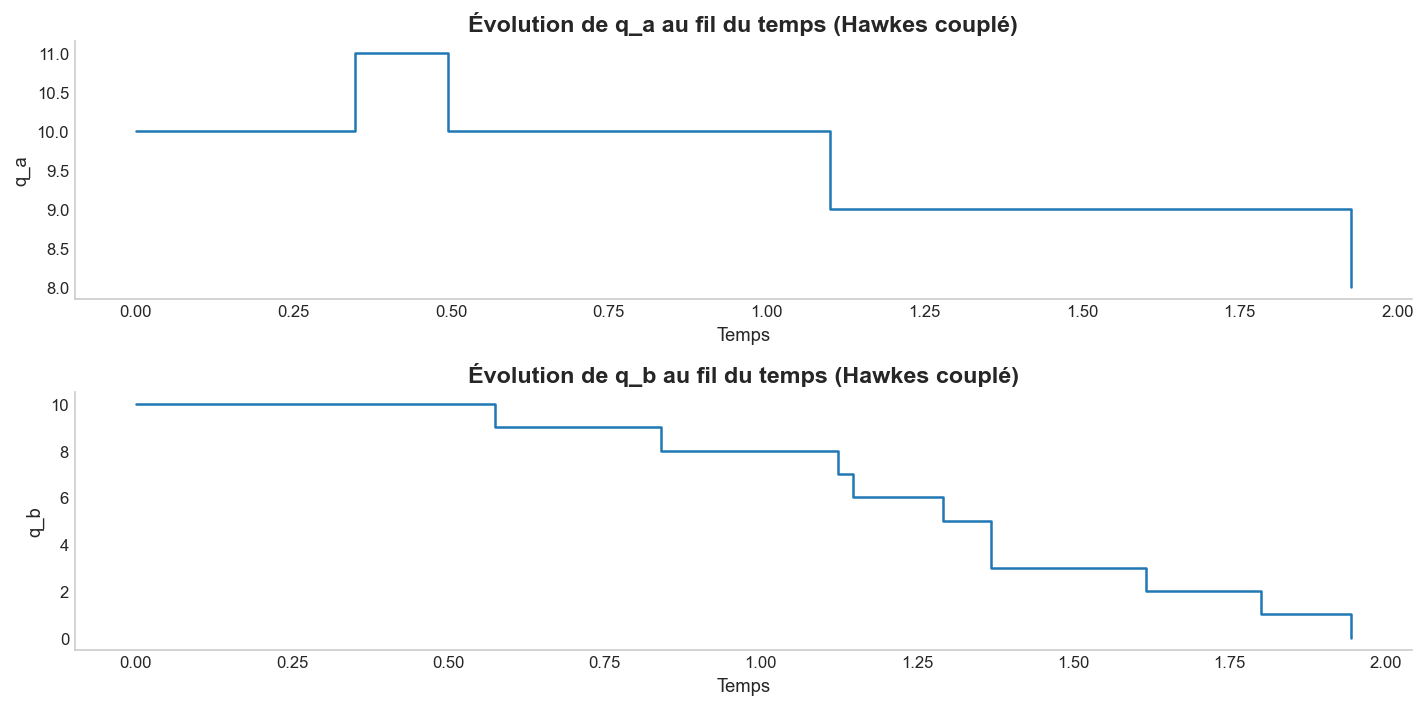

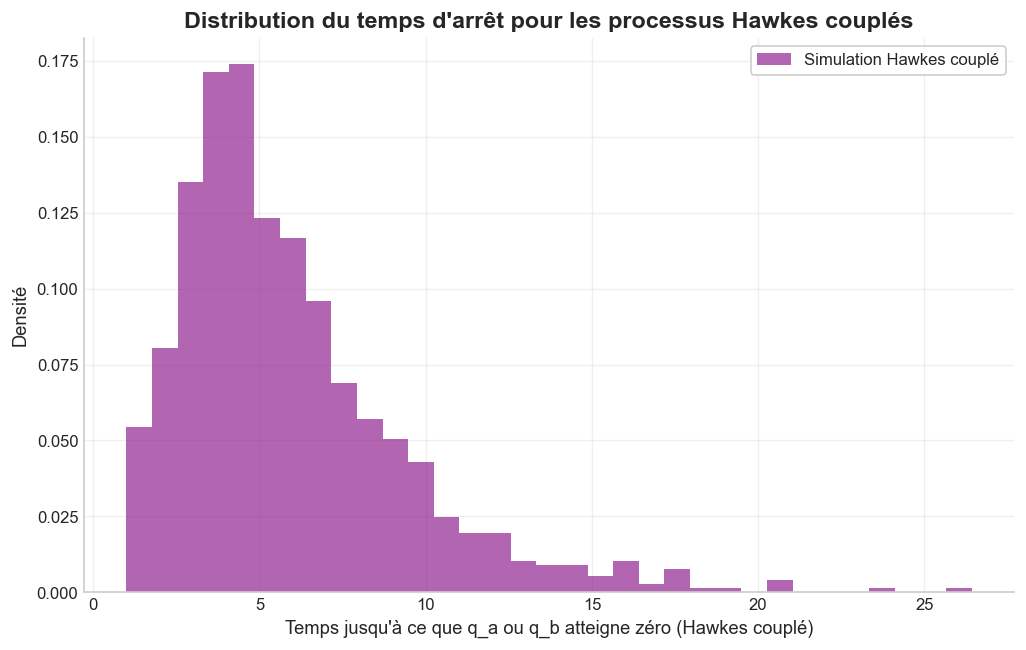

In [17]:
times,times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1.0, lambda_plus_a=1.2, lambda_plus_b=1.2, q_0_a=10, q_0_b=10)  
plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values)
plot_stopping_time_distribution_coupled_hawkes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1.0, lambda_plus_a=1.2, lambda_plus_b=1.2, q_0_a=10, q_0_b=10, num_simulations=1000)     


In [18]:
def plot_compare_hitting_times(lambda_plus, lambda_minus, mu_minus, alpha, beta, q_0, num_simulations=10):
    #use function that gfives distribution of hitting times for Hawkes process and poission process in section 1 , all functions are already predefinied
    poisson_hitting_times = simuler_plusieurs_temps_atteinte_poisson(lambda_plus, lambda_minus, q_0, num_simulations)
    hawkes_hitting_times = []
    for _ in range(num_simulations):      
        times, _, _, _, _ = trajectoire_carnet_dordre_hawkes(mu_minus, alpha, beta, lambda_plus, q_0, stopping_condition=lambda q,t: q==0)
        hawkes_hitting_times.append(times[-1])  
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(poisson_hitting_times, bins='auto', density=True, alpha=0.6, color='blue', label='Hitting times Poisson')
    plt.xlabel("Temps   d'atteinte de zéro (Poisson)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'atteinte de zéro pour le processus de Poisson")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.hist(hawkes_hitting_times, bins='auto', density=True, alpha=0.6, color='orange', label='Hitting times Hawkes')
    plt.xlabel("Temps d'atteinte de zéro (Hawkes)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'atteinte de zéro pour le processus de Hawkes")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()  


In [ ]:
plot_compare_hitting_times(lambda_plus=1.2, lambda_minus=2, mu_minus=2, alpha=0.5, beta=1.0, q_0=10, num_simulations=10)
